# 1. images pour le rapport

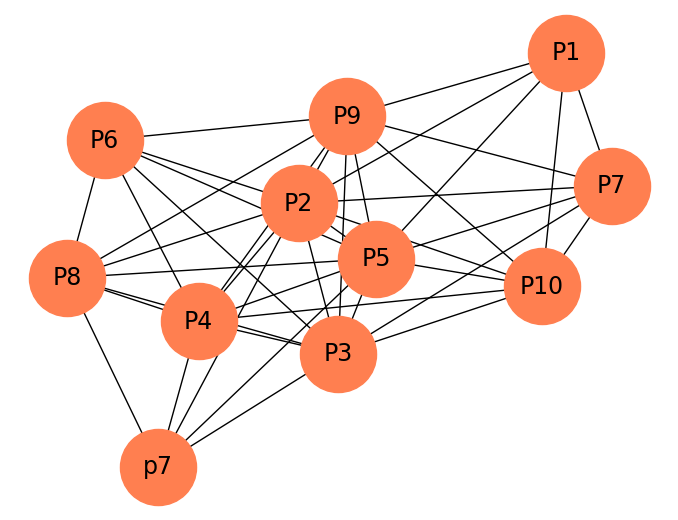

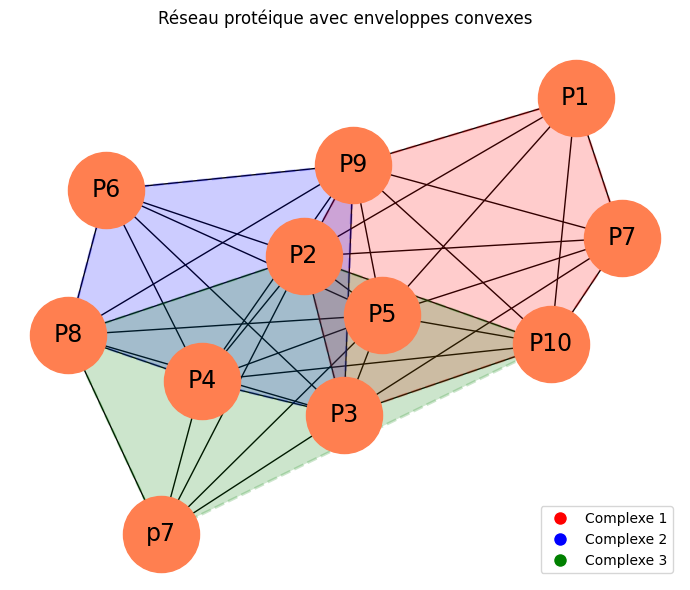

In [60]:

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Circle, Ellipse
from scipy.spatial import ConvexHull

# Créer un graph aléatoire avec des communautés (groupes denses)
np.random.seed(42)
num_proteins = 10
G = nx.Graph()

# Ajouter les noeuds P1 à P15
proteins = [f'P{i}' for i in range(1, num_proteins+1)]
G.add_nodes_from(proteins)

# Définir 3 communautés (complexes protéiques) qui se chevauchent partiellement
community1 = ['P1', 'P2', 'P3', 'P5', 'P7', 'P9', 'P10']
community2 = ['P4', 'P2', 'P3', 'P6', 'P8', 'P9']
community3 = ['P4', 'P2', 'P3', 'P5', 'p7', "P8", 'P10']

# Ajouter des connections denses dans les communautés
for u in community1:
    for v in community1:
        if u != v and np.random.random() < 0.8:
            G.add_edge(u, v)

for u in community2:
    for v in community2:
        if u != v and np.random.random() < 0.7:
            G.add_edge(u, v)

for u in community3:
    for v in community3:
        if u != v and np.random.random() < 0.6:
            G.add_edge(u, v)

# Ajouter quelques connections aléatoires entre communautés
for u in G.nodes():
    for v in G.nodes():
        if u != v and np.random.random() < 0.05:
            G.add_edge(u, v)

# Positionnement des noeuds avec un layout qui respecte les communautés
pos = nx.spring_layout(G, k=0.3, seed=42)
fig, ax = plt.subplots(figsize=(8.5, 6.5))

# Dessiner le réseau original
nx.draw_networkx(G, pos, ax=ax, with_labels=True, node_color='coral', 
                 node_size=3000, font_size=17, edge_color='black')
ax.set_axis_off()
 
# Calculer les positions et tailles des cercles englobants
def draw_community(ax, nodes, pos, color):
    points = np.array([pos[n] for n in nodes if n in pos])
    if len(points) < 3:  # Pas assez de points pour une enveloppe convexe
        return
    
    hull = ConvexHull(points)
    poly = plt.Polygon(points[hull.vertices], 
                      color=color, 
                      alpha=0.2, 
                      linestyle='--',
                      linewidth=2)
    ax.add_patch(poly)

# 3. Visualisation
pos = nx.spring_layout(G, k=0.3, seed=42)
fig, ax = plt.subplots(figsize=(7, 6))

# Dessiner le même réseau avec les cercles englobants
nx.draw_networkx(G, pos, ax=ax, with_labels=True, node_color='coral', 
                 node_size=3000, font_size=17, edge_color='black')




# Dessiner les communautés avec des couleurs distinctes
draw_community(ax, community1, pos, 'red')
draw_community(ax, community2, pos, 'blue')
draw_community(ax, community3, pos, 'green')
# Ajouter une légende
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Complexe 1', markerfacecolor='red', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Complexe 2', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Complexe 3', markerfacecolor='green', markersize=10)
]
ax.legend(handles=legend_elements, loc='lower right')

plt.title("Réseau protéique avec enveloppes convexes", pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

## 1.2. golden complexes

In [ ]:
import pandas as pd
from py4cytoscape import *
import time
import pandas as pd
from py4cytoscape import *
import time
import webbrowser

def launch_cytoscape():
    """Tente d'ouvrir Cytoscape automatiquement"""
    try:
        # Chemin par défaut sur Windows - adaptez si nécessaire
        webbrowser.open(r'C:\Program Files\Cytoscape_v3.10.3\Cytoscape.exe')  
        time.sleep(15)  # Temps de chargement
    except Exception as e:
        print("Impossible de lancer Cytoscape automatiquement. Veuillez l'ouvrir manuellement.")
        print(f"Erreur : {e}")

def connect_cytoscape(max_attempts=5, wait_time=10):
    """Tente de se connecter à Cytoscape avec plusieurs essais"""
    for attempt in range(max_attempts):
        try:
            cytoscape_ping()
            print("Connexion à Cytoscape établie avec succès!")
            return True
        except Exception as e:
            if attempt == max_attempts - 1:
                print("""
                Échec de connexion. Causes possibles :
                1. Cytoscape n'est pas lancé
                2. CyREST n'est pas installé (Apps > App Manager)
                3. Le port REST est bloqué (par défaut : 1234)
                4. Problème de firewall
                """)
                return False
            print(f"Tentative {attempt + 1}/{max_attempts} - Cytoscape non détecté...")
            time.sleep(wait_time)
    return False

# Tentative de lancement automatique
launch_cytoscape()

# Connexion
if not connect_cytoscape():
    exit()


def visualize_golden_complexes():
    # Vérification de la connexion à Cytoscape
    max_attempts = 3
    for attempt in range(max_attempts):
        try:
            cytoscape_ping()
            print("Connexion à Cytoscape établie avec succès.")
            break
        except:
            if attempt == max_attempts - 1:
                raise RuntimeError(
                    "Échec de la connexion à Cytoscape après 3 tentatives.\n"
                    "Veuillez :\n"
                    "1. Lancer Cytoscape\n"
                    "2. Vérifier que CyREST est installé (Apps → App Manager)\n"
                    "3. Redémarrer Cytoscape si nécessaire"
                )
            print(f"Tentative {attempt + 1} : Cytoscape non détecté, nouvelle tentative dans 5 secondes...")
            time.sleep(5)

    # Données pour 3 golden complexes
    complexes = {
        "Ribosome": ["RPL1", "RPL2", "RPL3", "RPL4", "RPS1", "RPS2", "RPS3"],
        "Proteasome 20S": ["PSMA1", "PSMA2", "PSMA3", "PSMB1", "PSMB2", "PSMB3"],
        "COP9 Signalosome": ["COPS2", "COPS3", "COPS4", "COPS5", "COPS6", "COPS7A"]
    }

    # Configuration visuelle de base
    default_style = {
        'NODE_FILL_COLOR': '#FFF900',
        'NODE_SIZE': 40,
        'EDGE_WIDTH': 2,
        'EDGE_COLOR': '#CCCCCC'
    }

    # Création des réseaux
    for nom_complexe, proteines in complexes.items():
        print(f"Traitement du complexe : {nom_complexe}")
        
        # Création des interactions (graphe complet)
        edges = [(proteines[i], proteines[j]) 
                for i in range(len(proteines)) 
                for j in range(i+1, len(proteines))]
        
        # Création du réseau
        network = create_network_from_data_frames(
            edges=pd.DataFrame(edges, columns=["source", "target"]),
            title=f"Golden Complex: {nom_complexe}",
            collection="Golden Complexes"
        )
        
        # Application du style
        create_visual_style(
            style_name=f"style_{nom_complexe}",
            defaults=default_style,
            mappings=None
        )
        set_visual_style(f"style_{nom_complexe}", network=network)
        
        # Disposition et étiquettes
        layout_network(layout_name="force-directed", network=network)
        set_node_label_mapping(table_column="name", style_name=f"style_{nom_complexe}")
        
        # Export image
        export_image(filename=f"{nom_complexe}.png", type="PNG")
        print(f"Complexe {nom_complexe} exporté sous {nom_complexe}.png")

    # Sauvegarde de la session
    save_session(filename="golden_complexes.cys")
    print("Session sauvegardée sous golden_complexes.cys")

if __name__ == "__main__":
    visualize_golden_complexes()

You are connected to Cytoscape!
Connexion à Cytoscape établie avec succès!
You are connected to Cytoscape!
Connexion à Cytoscape établie avec succès.
Traitement du complexe : Ribosome
Applying default style...
Applying preferred layout
Complexe Ribosome exporté sous Ribosome.png
Traitement du complexe : Proteasome 20S
Applying default style...
Applying preferred layout
Complexe Proteasome 20S exporté sous Proteasome 20S.png
Traitement du complexe : COP9 Signalosome
Applying default style...
Applying preferred layout
Complexe COP9 Signalosome exporté sous COP9 Signalosome.png
This file has been overwritten.
Session sauvegardée sous golden_complexes.cys


In [9]:
import networkx as nx
import matplotlib.pyplot as plt

complexes = {
    "Ribosome": ["RPL1", "RPL2", "RPL3", "RPL4", "RPS1", "RPS2", "RPS3"],
    "Proteasome 20S": ["PSMA1", "PSMA2", "PSMA3", "PSMB1", "PSMB2", "PSMB3"],
    "COP9 Signalosome": ["COPS2", "COPS3", "COPS4", "COPS5", "COPS6", "COPS7A"]
}

for name, proteins in complexes.items():
    G = nx.Graph()
    G.add_nodes_from(proteins)
    # Add all possible interactions (complete graph)
    for i in range(len(proteins)):
        for j in range(i+1, len(proteins)):
            G.add_edge(proteins[i], proteins[j])
    
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='orange', 
            node_size=2000, font_size=10, font_weight='bold')
    plt.title(f"Golden Complex: {name}")
    plt.savefig(f"{name}_network.png")
    plt.close()
    print(f"Saved {name}_network.png")

Saved Ribosome_network.png
Saved Proteasome 20S_network.png
Saved COP9 Signalosome_network.png
